In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["svg.fonttype"] = "none"

# CB6644 data

In [4]:
layout1 = pd.read_csv("/Users/alexandergillis/Desktop/KATANA_PULL/blana/Alex/250912_mACmChPOLR2A_smFISH/250912_mACmChPOLR2A_smFISH.csv")
layout2 = pd.read_csv("/Users/alexandergillis/Desktop/KATANA_PULL/blana/Alex/250922_mACmChPOLR2A_smFISH/250922_mACmChPOLR2A_smFISH.csv")
layout3 = pd.read_csv("/Users/alexandergillis/Desktop/KATANA_PULL/blana/Alex/251031_mACmChPOLR2A_smFISH/251031_mACmChPOLR2A_smFISH.csv")

## load quantification files from relevant directories, and assemble into data frames

In [5]:
quantification_directory_1 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/250912_mACmChPOLR2A_smFISH/20250916_165545_947/QUANTIFICATION/")
quantification_files_1 = glob.glob(str(quantification_directory_1 / "*.csv"))

quantification_directory_2 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/250922_mACmChPOLR2A_smFISH/20250926_174737_585/QUANTIFICATION")
quantification_files_2 = glob.glob(str(quantification_directory_2 / "*.csv"))

quantification_directory_3 = Path("/Users/alexandergillis/Desktop/KATANA_PULL//251031_mACmChPOLR2A_smFISH/20251104_181151_686/QUANTIFICATION/")
quantification_files_3 = glob.glob(str(quantification_directory_3 / "*.csv"))

len(quantification_files_1), len(quantification_files_2), len(quantification_files_3)

(860, 890, 900)

In [6]:
Nuclei_quant_files_1 = [i for i in quantification_files_1 if "nuclei_" in i]
Cell_quant_files_1 = [i for i in quantification_files_1 if "cells_" in i]

Nuclei_quant_files_2 = [i for i in quantification_files_2 if "nuclei_" in i]
Cell_quant_files_2 = [i for i in quantification_files_2 if "cells_" in i]

Nuclei_quant_files_3 = [i for i in quantification_files_3 if "nuclei_" in i]
Cell_quant_files_3 = [i for i in quantification_files_3 if "cells_" in i]

In [7]:
qdfs = list()

for f in tqdm(Cell_quant_files_1):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_1['file'].tolist()


wellnames = [f[6:12] for f in files]
quantifcation_percell_1['well'] = wellnames

fovs = [f[44:48] for f in files]
quantifcation_percell_1['fov'] = fovs

quantifcation_percell_1 = quantifcation_percell_1.query('Cells_3D_is_border == False')

Quantification = pd.DataFrame({
    "WELL" : quantifcation_percell_1['well'],
    "FOV" : quantifcation_percell_1['fov'],
    "LABEL" : quantifcation_percell_1['label'],
    "CellVolume" : quantifcation_percell_1['Cells_3D_physical_volume_pL'],
    "Spots_565" : quantifcation_percell_1['FISH_Channel1_SpotsPerCell'],
    "Spots_633" : quantifcation_percell_1['FISH_Channel2_SpotsPerCell']
})

qdfs = list()


for f in tqdm(Nuclei_quant_files_1):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_1['file'].tolist()


wellnames = [f[7:13] for f in files]
quantifcation_pernuc_1['well'] = wellnames

fovs = [f[45:49] for f in files]
quantifcation_pernuc_1['fov'] = fovs

QuantificationNuclei = pd.DataFrame({
    "WELL" : quantifcation_pernuc_1['well'],
    "FOV" : quantifcation_pernuc_1['fov'],
    "LABEL" : quantifcation_pernuc_1['label'],
    "NucleiVolume" : quantifcation_pernuc_1['Nuclei_3D_physical_volume_pL'],
    "Nuclei561Mean" : quantifcation_pernuc_1['Nuclei_3D_intensity_mean_561'],
    "Nuclei405Mean" : quantifcation_pernuc_1['Nuclei_3D_intensity_mean_405']
})

100%|████████████████████████████████████████| 430/430 [00:01<00:00, 236.33it/s]


In [8]:
Quantification = Quantification.merge(QuantificationNuclei, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])
Quantification.dropna(inplace = True)
Quantification = Quantification.query('NucleiVolume > 0.5')
Quantification['EXPERIMENT'] = np.tile('250912', len(Quantification.index))
QuantificationNoLayout = Quantification

In [9]:
qdfs = list()

for f in tqdm(Cell_quant_files_2):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_2['file'].tolist()


wellnames = [f[6:12] for f in files]
quantifcation_percell_2['well'] = wellnames

fovs = [f[44:48] for f in files]
quantifcation_percell_2['fov'] = fovs

quantifcation_percell_2 = quantifcation_percell_2.query('Cells_3D_is_border == False')

Quantification2 = pd.DataFrame({
    "WELL" : quantifcation_percell_2['well'],
    "FOV" : quantifcation_percell_2['fov'],
    "LABEL" : quantifcation_percell_2['label'],
    "CellVolume" : quantifcation_percell_2['Cells_3D_physical_volume_pL'],
    "Spots_565" : quantifcation_percell_2['FISH_Channel1_SpotsPerCell'],
    "Spots_633" : quantifcation_percell_2['FISH_Channel2_SpotsPerCell']
})

qdfs = list()


for f in tqdm(Nuclei_quant_files_2):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_2['file'].tolist()


wellnames = [f[7:13] for f in files]
quantifcation_pernuc_2['well'] = wellnames

fovs = [f[45:49] for f in files]
quantifcation_pernuc_2['fov'] = fovs

QuantificationNuclei2 = pd.DataFrame({
    "WELL" : quantifcation_pernuc_2['well'],
    "FOV" : quantifcation_pernuc_2['fov'],
    "LABEL" : quantifcation_pernuc_2['label'],
    "NucleiVolume" : quantifcation_pernuc_2['Nuclei_3D_physical_volume_pL'],
    "Nuclei561Mean" : quantifcation_pernuc_2['Nuclei_3D_intensity_mean_561'],
    "Nuclei405Mean" : quantifcation_pernuc_2['Nuclei_3D_intensity_mean_405']
})

100%|████████████████████████████████████████| 445/445 [00:01<00:00, 250.62it/s]


In [10]:
Quantification2 = Quantification2.merge(QuantificationNuclei2, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])
Quantification2.dropna(inplace = True)
Quantification2 = Quantification2.query('NucleiVolume > 0.5')
Quantification2['EXPERIMENT'] = np.tile('250922', len(Quantification2.index))
QuantificationNoLayout2 = Quantification2

In [11]:
qdfs = list()

for f in tqdm(Cell_quant_files_3):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_3 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_3['file'].tolist()


wellnames = [f[6:12] for f in files]
quantifcation_percell_3['well'] = wellnames

fovs = [f[44:48] for f in files]
quantifcation_percell_3['fov'] = fovs

quantifcation_percell_3 = quantifcation_percell_3.query('Cells_3D_is_border == False')

Quantification3 = pd.DataFrame({
    "WELL" : quantifcation_percell_3['well'],
    "FOV" : quantifcation_percell_3['fov'],
    "LABEL" : quantifcation_percell_3['label'],
    "CellVolume" : quantifcation_percell_3['Cells_3D_physical_volume_pL'],
    "Spots_565" : quantifcation_percell_3['FISH_Channel1_SpotsPerCell'],
    "Spots_633" : quantifcation_percell_3['FISH_Channel2_SpotsPerCell']
})

qdfs = list()


for f in tqdm(Nuclei_quant_files_3):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_3 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_3['file'].tolist()


wellnames = [f[7:13] for f in files]
quantifcation_pernuc_3['well'] = wellnames

fovs = [f[45:49] for f in files]
quantifcation_pernuc_3['fov'] = fovs

QuantificationNuclei3 = pd.DataFrame({
    "WELL" : quantifcation_pernuc_3['well'],
    "FOV" : quantifcation_pernuc_3['fov'],
    "LABEL" : quantifcation_pernuc_3['label'],
    "NucleiVolume" : quantifcation_pernuc_3['Nuclei_3D_physical_volume_pL'],
    "Nuclei561Mean" : quantifcation_pernuc_3['Nuclei_3D_intensity_mean_561'],
    "Nuclei405Mean" : quantifcation_pernuc_3['Nuclei_3D_intensity_mean_405']
})

100%|████████████████████████████████████████| 450/450 [00:01<00:00, 249.98it/s]


In [12]:
Quantification3 = Quantification3.merge(QuantificationNuclei3, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])
Quantification3.dropna(inplace = True)
Quantification3 = Quantification3.query('NucleiVolume > 0.5')
Quantification3['EXPERIMENT'] = np.tile('251031', len(Quantification3.index))
QuantificationNoLayout3 = Quantification3

In [13]:
Quantification = Quantification.merge(layout1, how = 'left', left_on = "WELL", right_on = "WELL")
Quantification2 = Quantification2.merge(layout2, how = 'left', left_on = "WELL", right_on = "WELL")
Quantification3 = Quantification3.merge(layout3, how = 'left', left_on = "WELL", right_on = "WELL")

In [14]:
QuantificationMultiple = pd.concat([Quantification, Quantification2, Quantification3])

## filter for relevant wells

In [15]:
QuantificationMultiple = QuantificationMultiple.query('TREATMENT in ["Vehicle", "CB6644"] & CELL == "OsTIRF74G"')

## check main effects over experiments

In [16]:
QuantificationMultiple.ATTO633_PROBE.unique()

array(['POLR2B odd', 'GAPDH', 'POLR2A even', 'mrcB', 'POLR2B even'],
      dtype=object)

<Axes: xlabel='TREATMENT', ylabel='Spots_633'>

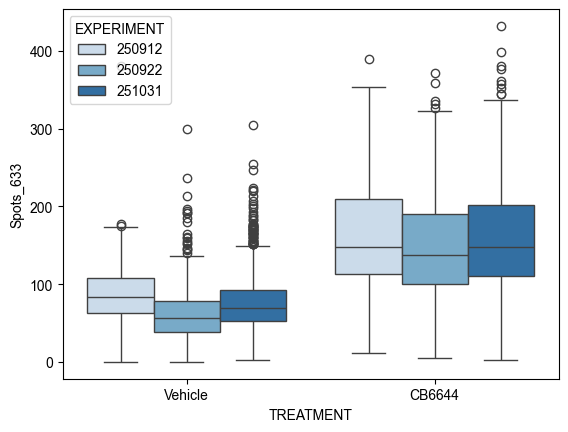

In [18]:
sns.boxplot(QuantificationMultiple.query('ATTO633_PROBE == "POLR2A even"'),
            x = 'TREATMENT', order = ['Vehicle','CB6644'],
            y = 'Spots_633',
            hue = 'EXPERIMENT', dodge = True, palette = 'Blues')

<Axes: xlabel='TREATMENT', ylabel='CellVolume'>

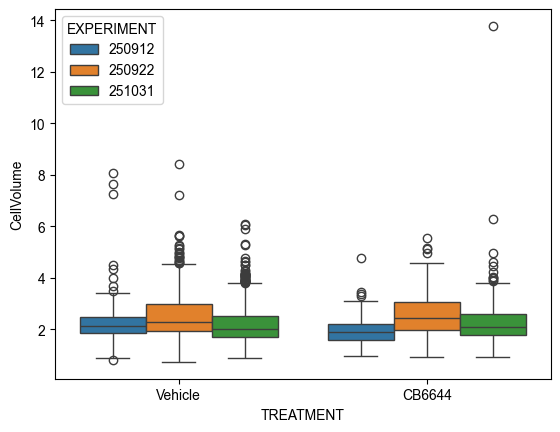

In [20]:
sns.boxplot(QuantificationMultiple.query('ATTO633_PROBE == "POLR2A even"'),
            x = 'TREATMENT', order = ['Vehicle','CB6644'],
            y = 'CellVolume',
            hue = 'EXPERIMENT', dodge = True)

In [21]:
QuantificationMultiple['Spots_633_per_pL'] = QuantificationMultiple['Spots_633'] / QuantificationMultiple['CellVolume']
QuantificationMultiple['Spots_565_per_pL'] = QuantificationMultiple['Spots_565'] / QuantificationMultiple['CellVolume']

In [69]:
QuantificationMultiple['REPLICATE'] = QuantificationMultiple['EXPERIMENT'].map(dict(zip(QuantificationMultiple.EXPERIMENT.unique().tolist(), ['Replicate 1','Replicate 2','Replicate 3'])))

In [70]:
QuantificationMultiple.query('ATTO633_PROBE == "POLR2A even" & ATTO565_PROBE in ["POLR2B even", "POLR2B odd"] & EXPERIMENT == "250912"').TREATMENT.unique()

array(['CB6644'], dtype=object)

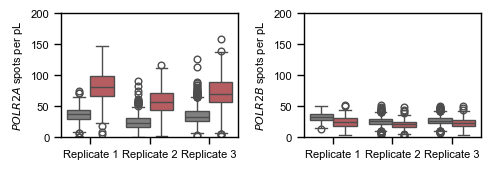

In [71]:
f, a = plt.subplots(figsize = (5,1.8), ncols = 2)

pal = sns.color_palette(['grey', sns.color_palette('deep')[3]])

h = sns.boxplot(QuantificationMultiple.query('ATTO633_PROBE == "POLR2A even" & TREATMENT != "LMB"'),
            ax = a[0],
            x = 'REPLICATE',
            y = 'Spots_633_per_pL',
            hue = 'TREATMENT', hue_order = ['Vehicle','CB6644'], palette = pal)
h.get_legend().remove()

h = sns.boxplot(QuantificationMultiple.query('ATTO565_PROBE in ["POLR2B even", "POLR2B odd"] & TREATMENT != "LMB"'),
            ax = a[1],
            x = 'REPLICATE',
            y = 'Spots_565_per_pL',
            hue = 'TREATMENT', hue_order = ['Vehicle','CB6644'], palette = pal)
h.get_legend().remove()

a[0].set_ylabel('$POLR2A$ spots per pL', fontsize = 8)
a[0].set_xlabel('')
a[0].tick_params(axis = 'both', labelsize = 8)
a[0].set_ylim(0,200)
a[0].set_box_aspect(0.7)

a[1].set_ylabel('$POLR2B$ spots per pL', fontsize = 8)
a[1].set_xlabel('')
a[1].tick_params(axis = 'both', labelsize = 8)
a[1].set_ylim(0,200)
a[1].set_box_aspect(0.7)

plt.tight_layout()

plt.savefig('POLR2A_POLR2B_CB6644_3repeats.svg')

## bin volumes and plot combined replicates

In [72]:
binz = [p/100 for p in range(100,580,80)]
binz_centre = []
for i,b in enumerate(binz[:-1]):
    g = (binz[i+1] - b)
    h = b + g/2
    binz_centre.append(h)

(0.0, 8.0)

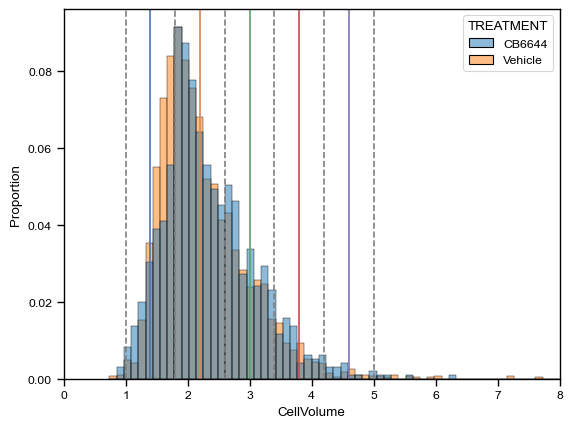

In [73]:
sns.histplot(QuantificationMultiple.query('ATTO633_PROBE == "POLR2A even"'),
             x = 'CellVolume',
             hue = 'TREATMENT',
             stat = 'proportion', common_norm = False)

clrs = sns.color_palette('deep')

for i,b in enumerate(binz):
    plt.axvline(b, c = 'grey', linestyle = '--')

for i,b in enumerate(binz_centre):
    plt.axvline(b, c = clrs[i])

plt.xlim(0,8)

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site

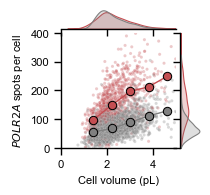

In [74]:
TIR_POLA_POLB = QuantificationMultiple.query('ATTO633_PROBE == "POLR2A even" & ATTO565_PROBE in ["POLR2B even", "POLR2B odd"]')

TIR_VEH = TIR_POLA_POLB.query('TREATMENT == "Vehicle"')
TIR_VEH_MEAN = TIR_VEH[['CellVolume','Spots_633']].groupby(pd.cut(TIR_VEH.CellVolume, binz)).mean()

TIR_CB = TIR_POLA_POLB.query('TREATMENT == "CB6644"')
TIR_CB_MEAN = TIR_CB[['CellVolume','Spots_633']].groupby(pd.cut(TIR_CB.CellVolume, binz)).mean()

sns.set_context('paper')

pal = sns.color_palette(['grey', sns.color_palette('deep')[3]])

sns.jointplot(TIR_POLA_POLB.query('TREATMENT in ["Vehicle", "CB6644"]'),
              x = 'CellVolume',
              y = 'Spots_633',
              hue = 'TREATMENT', hue_order = ['Vehicle', 'CB6644'], palette = pal,
              s = 5,
              legend = False,
              ylim = (0,400),
              xlim = (0,5), 
              marginal_kws={'common_norm': False},
              joint_kws = {'alpha' : 0.3},
              height = 1.8)
              
sns.lineplot(x = binz_centre,
             y = TIR_VEH_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = 'grey')

sns.lineplot(x = binz_centre,
             y = TIR_CB_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = sns.color_palette('deep')[3])

plt.xlabel('Cell volume (pL)', fontsize = 8)
plt.ylabel('$POLR2A$ spots per cell', fontsize = 8)
plt.tick_params(axis = 'both', labelsize = 8)

plt.savefig('TIR_POLR2A_CB6644_smFISH_3reps.svg')

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site

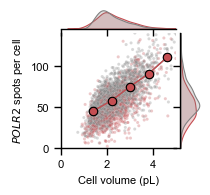

In [75]:
TIR_POLA_POLB = QuantificationMultiple.query('ATTO633_PROBE == "POLR2A even" & ATTO565_PROBE in ["POLR2B even", "POLR2B odd"]')

TIR_VEH = TIR_POLA_POLB.query('TREATMENT == "Vehicle"')
TIR_VEH_POLR2B_MEAN = TIR_VEH[['CellVolume','Spots_565']].groupby(pd.cut(TIR_VEH.CellVolume, binz)).mean()

TIR_CB = TIR_POLA_POLB.query('TREATMENT == "CB6644"')
TIR_CB_POLR2B_MEAN = TIR_CB[['CellVolume','Spots_565']].groupby(pd.cut(TIR_CB.CellVolume, binz)).mean()

sns.set_context('paper')

pal = sns.color_palette(['grey', sns.color_palette('deep')[3]])

sns.jointplot(TIR_POLA_POLB.query('TREATMENT in ["Vehicle", "CB6644"]'),
              x = 'CellVolume',
              y = 'Spots_565',
              hue = 'TREATMENT', hue_order = ['Vehicle', 'CB6644'], palette = pal,
              s = 5,
              legend = False,
              ylim = (0,140),
              xlim = (0,5), 
              marginal_kws={'common_norm': False},
              joint_kws = {'alpha' : 0.3},
              height = 1.8)
              
sns.lineplot(x = binz_centre,
             y = TIR_VEH_POLR2B_MEAN.Spots_565,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = 'grey')

sns.lineplot(x = binz_centre,
             y = TIR_VEH_POLR2B_MEAN.Spots_565,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = sns.color_palette('deep')[3])

plt.xlabel('Cell volume (pL)', fontsize = 8)
plt.ylabel('$POLR2$ spots per cell', fontsize = 8)
plt.tick_params(axis = 'both', labelsize = 8)

plt.savefig('TIR_POLR2B_CB6644_smFISH_3reps.svg')

In [76]:
QuantificationMultiple['Spots633_per_pL'] = QuantificationMultiple['Spots_633'] / QuantificationMultiple['CellVolume']

In [77]:
QuantificationMultiple['Replicate'] = QuantificationMultiple['EXPERIMENT'].map(dict(zip(
    QuantificationMultiple['EXPERIMENT'].unique().tolist(), 
    ['Replicate 1', 'Replicate 2', 'Replicate 3'])))

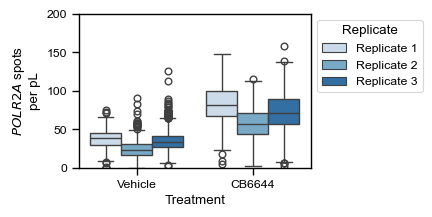

In [78]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (3,2))

h = sns.boxplot(QuantificationMultiple.query('ATTO633_PROBE == "POLR2A even"'),
            x = 'TREATMENT', order = ['Vehicle','CB6644'],
            y = 'Spots633_per_pL',
            hue = 'Replicate', dodge = True, palette = 'Blues')

a.set_ylabel('$POLR2A$ spots\nper pL')
a.set_xlabel('Treatment')

a.set_ylim(0,200)

sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

plt.savefig('OsTIRFG_Veh_CB6644_perpL_3reps.svg')

In [79]:
Vehicle_CB6644_ByReplicate = QuantificationMultiple.query('ATTO633_PROBE == "POLR2A even"')[['REPLICATE', 'TREATMENT', 'Spots633_per_pL']].groupby(['REPLICATE', 'TREATMENT']).mean().reset_index()

# AZD4574 and triptolide data

In [80]:
layout1 = pd.read_csv("/Users/alexandergillis/Desktop/KATANA_PULL/blana/Alex/251031_mACmChPOLR2A_smFISH/251031_mACmChPOLR2A_smFISH.csv")
layout2 = pd.read_csv("/Users/alexandergillis/Desktop/KATANA_PULL/blana/Alex/251114_Inhibitors_smFISH/251114_Inhibitor_smFISH.csv")

## load quantification files from relevant directories, and assemble into data frames

In [81]:
quantification_directory_1 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/251031_mACmChPOLR2A_smFISH/20251104_181151_686/QUANTIFICATION")
quantification_files_1 = glob.glob(str(quantification_directory_1 / "*.csv"))
len(quantification_files_1)

900

In [82]:
quantification_directory_2 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/251114_Inhibitors_smFISH/20251118_174542_824/QUANTIFICATION")
quantification_files_2 = glob.glob(str(quantification_directory_2 / "*.csv"))
len(quantification_files_2)

888

In [83]:
Nuclei_quant_files_1 = [i for i in quantification_files_1 if "nuclei_" in i]
Cell_quant_files_1 = [i for i in quantification_files_1 if "cells_" in i]

Nuclei_quant_files_2 = [i for i in quantification_files_2 if "nuclei_" in i]
Cell_quant_files_2 = [i for i in quantification_files_2 if "cells_" in i]

In [84]:
qdfs = list()

for f in tqdm(Cell_quant_files_1):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_1['file'].tolist()


wellnames = [f[6:12] for f in files]
quantifcation_percell_1['well'] = wellnames

fovs = [f[44:48] for f in files]
quantifcation_percell_1['fov'] = fovs

quantifcation_percell_1 = quantifcation_percell_1.query('Cells_3D_is_border == False')

Quantification = pd.DataFrame({
    "WELL" : quantifcation_percell_1['well'],
    "FOV" : quantifcation_percell_1['fov'],
    "LABEL" : quantifcation_percell_1['label'],
    "CellVolume" : quantifcation_percell_1['Cells_3D_physical_volume_pL'],
    "Spots_565" : quantifcation_percell_1['FISH_Channel1_SpotsPerCell'],
    "Spots_633" : quantifcation_percell_1['FISH_Channel2_SpotsPerCell']
})

qdfs = list()


for f in tqdm(Nuclei_quant_files_1):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_1['file'].tolist()


wellnames = [f[7:13] for f in files]
quantifcation_pernuc_1['well'] = wellnames

fovs = [f[45:49] for f in files]
quantifcation_pernuc_1['fov'] = fovs

QuantificationNuclei = pd.DataFrame({
    "WELL" : quantifcation_pernuc_1['well'],
    "FOV" : quantifcation_pernuc_1['fov'],
    "LABEL" : quantifcation_pernuc_1['label'],
    "NucleiVolume" : quantifcation_pernuc_1['Nuclei_3D_physical_volume_pL'],
    "Nuclei561Mean" : quantifcation_pernuc_1['Nuclei_3D_intensity_mean_561'],
    "Nuclei405Mean" : quantifcation_pernuc_1['Nuclei_3D_intensity_mean_405']
})

100%|████████████████████████████████████████| 450/450 [00:01<00:00, 232.63it/s]


In [85]:
Quantification = Quantification.merge(QuantificationNuclei, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])
Quantification.dropna(inplace = True)
Quantification = Quantification.query('NucleiVolume > 0.5')
Quantification['EXPERIMENT'] = '251031'
QuantificationNoLayout = Quantification

In [86]:
qdfs = list()

for f in tqdm(Cell_quant_files_2):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_2['file'].tolist()


wellnames = [f[6:12] for f in files]
quantifcation_percell_2['well'] = wellnames

fovs = [f[44:48] for f in files]
quantifcation_percell_2['fov'] = fovs

quantifcation_percell_2 = quantifcation_percell_2.query('Cells_3D_is_border == False')

Quantification2 = pd.DataFrame({
    "WELL" : quantifcation_percell_2['well'],
    "FOV" : quantifcation_percell_2['fov'],
    "LABEL" : quantifcation_percell_2['label'],
    "CellVolume" : quantifcation_percell_2['Cells_3D_physical_volume_pL'],
    "Spots_565" : quantifcation_percell_2['FISH_Channel1_SpotsPerCell'],
    "Spots_633" : quantifcation_percell_2['FISH_Channel2_SpotsPerCell']
})

qdfs = list()


for f in tqdm(Nuclei_quant_files_2):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_2['file'].tolist()


wellnames = [f[7:13] for f in files]
quantifcation_pernuc_2['well'] = wellnames

fovs = [f[45:49] for f in files]
quantifcation_pernuc_2['fov'] = fovs

QuantificationNuclei2 = pd.DataFrame({
    "WELL" : quantifcation_pernuc_2['well'],
    "FOV" : quantifcation_pernuc_2['fov'],
    "LABEL" : quantifcation_pernuc_2['label'],
    "NucleiVolume" : quantifcation_pernuc_2['Nuclei_3D_physical_volume_pL'],
    "Nuclei561Mean" : quantifcation_pernuc_2['Nuclei_3D_intensity_mean_561'],
    "Nuclei405Mean" : quantifcation_pernuc_2['Nuclei_3D_intensity_mean_405']
})

100%|████████████████████████████████████████| 444/444 [00:01<00:00, 268.83it/s]


In [87]:
Quantification2 = Quantification2.merge(QuantificationNuclei2, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])
Quantification2.dropna(inplace = True)
Quantification2 = Quantification2.query('NucleiVolume > 0.5')
Quantification2['EXPERIMENT'] = '251114'
QuantificationNoLayout2 = Quantification2

In [88]:
Quantification = Quantification.merge(layout1, how = 'left', left_on = "WELL", right_on = "WELL")
Quantification2 = Quantification2.merge(layout2, how = 'left', left_on = "WELL", right_on = "WELL")

In [89]:
## filter for vehicle vs tpl vs azd

In [90]:
Quantification = Quantification.query('WELL in ["Well13", "Well16", "Well17"]')
Quantification2 = Quantification2.query('WELL in ["Well18", "Well15", "Well17"]')

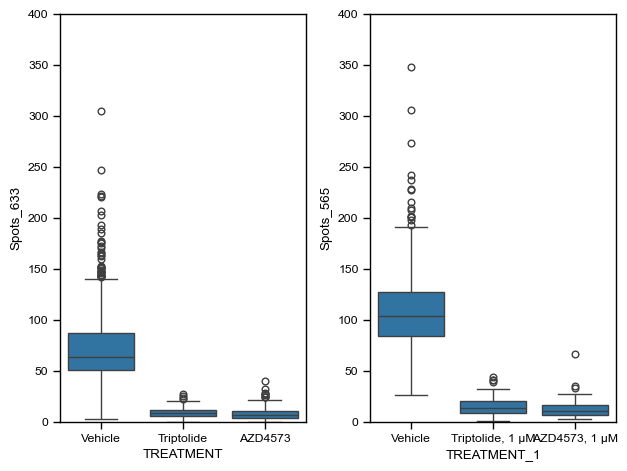

In [91]:
f, a = plt.subplots(ncols = 2)

sns.boxplot(Quantification,
            x = 'TREATMENT', order = ['Vehicle', 'Triptolide', 'AZD4573'],
            y = 'Spots_633',
            ax = a[0])

sns.boxplot(Quantification2,
            x = 'TREATMENT_1', order = ['Vehicle', 'Triptolide, 1 µM', 'AZD4573, 1 µM'],
            y = 'Spots_565',
            ax = a[1])

for i in [0,1]:
    a[i].set_ylim(0,400)

plt.tight_layout()

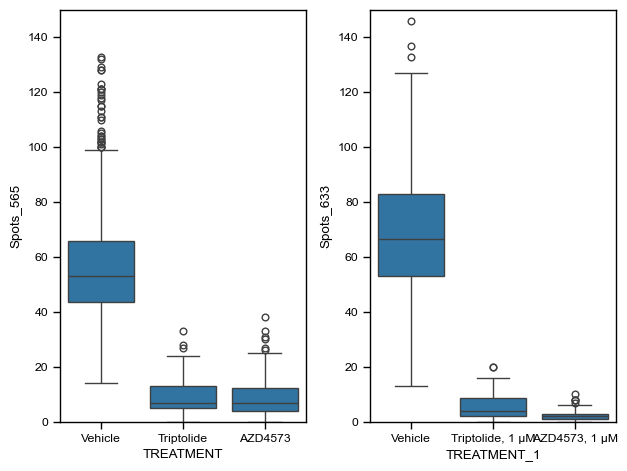

In [92]:
f, a = plt.subplots(ncols = 2)

sns.boxplot(Quantification,
            x = 'TREATMENT', order = ['Vehicle', 'Triptolide', 'AZD4573'],
            y = 'Spots_565',
            ax = a[0])

sns.boxplot(Quantification2,
            x = 'TREATMENT_1', order = ['Vehicle', 'Triptolide, 1 µM', 'AZD4573, 1 µM'],
            y = 'Spots_633',
            ax = a[1])

for i in [0,1]:
    a[i].set_ylim(0,150)

plt.tight_layout()

In [93]:
Experiment1_Vehicle_POLR2A = Quantification.query('TREATMENT == "Vehicle"')
Experiment2_Vehicle_POLR2A = Quantification2.query('TREATMENT_1 == "Vehicle"')

Experiment1_TPL_POLR2A = Quantification.query('TREATMENT == "Triptolide"')
Experiment2_TPL_POLR2A = Quantification2.query('TREATMENT_1 == "Triptolide, 1 µM"')

Experiment1_AZD_POLR2A = Quantification.query('TREATMENT == "AZD4573"')
Experiment2_AZD_POLR2A = Quantification2.query('TREATMENT_1 == "AZD4573, 1 µM"')

In [94]:
Experiment1_Vehicle_POLR2A = Experiment1_Vehicle_POLR2A[['WELL', 'EXPERIMENT', 'CellVolume','Spots_633']]
Experiment1_Vehicle_POLR2A['PROBE'] = 'POLR2A'
Experiment1_Vehicle_POLR2A['TREATMENT'] = 'Vehicle'
Experiment1_Vehicle_POLR2A.rename(columns = {'Spots_633' : 'SPOTS_PER_CELL'}, inplace = True)
Experiment1_Vehicle_POLR2A['SPOTS_PER_PL'] = Experiment1_Vehicle_POLR2A['SPOTS_PER_CELL'] / Experiment1_Vehicle_POLR2A['CellVolume']

Experiment1_TPL_POLR2A = Experiment1_TPL_POLR2A[['WELL', 'EXPERIMENT', 'CellVolume','Spots_633']]
Experiment1_TPL_POLR2A['PROBE'] = 'POLR2A'
Experiment1_TPL_POLR2A['TREATMENT'] = 'Triptolide'
Experiment1_TPL_POLR2A.rename(columns = {'Spots_633' : 'SPOTS_PER_CELL'}, inplace = True)
Experiment1_TPL_POLR2A['SPOTS_PER_PL'] = Experiment1_TPL_POLR2A['SPOTS_PER_CELL'] / Experiment1_TPL_POLR2A['CellVolume']

Experiment1_AZD_POLR2A = Experiment1_AZD_POLR2A[['WELL', 'EXPERIMENT', 'CellVolume','Spots_633']]
Experiment1_AZD_POLR2A['PROBE'] = 'POLR2A'
Experiment1_AZD_POLR2A['TREATMENT'] = 'AZD4573'
Experiment1_AZD_POLR2A.rename(columns = {'Spots_633' : 'SPOTS_PER_CELL'}, inplace = True)
Experiment1_AZD_POLR2A['SPOTS_PER_PL'] = Experiment1_AZD_POLR2A['SPOTS_PER_CELL'] / Experiment1_AZD_POLR2A['CellVolume']

Experiment2_Vehicle_POLR2A = Experiment2_Vehicle_POLR2A[['WELL', 'EXPERIMENT', 'CellVolume','Spots_565']]
Experiment2_Vehicle_POLR2A['PROBE'] = 'POLR2A'
Experiment2_Vehicle_POLR2A['TREATMENT'] = 'Vehicle'
Experiment2_Vehicle_POLR2A.rename(columns = {'Spots_565' : 'SPOTS_PER_CELL'}, inplace = True)
Experiment2_Vehicle_POLR2A['SPOTS_PER_PL'] = Experiment2_Vehicle_POLR2A['SPOTS_PER_CELL'] / Experiment2_Vehicle_POLR2A['CellVolume']

Experiment2_TPL_POLR2A = Experiment2_TPL_POLR2A[['WELL', 'EXPERIMENT', 'CellVolume','Spots_565']]
Experiment2_TPL_POLR2A['PROBE'] = 'POLR2A'
Experiment2_TPL_POLR2A['TREATMENT'] = 'Triptolide'
Experiment2_TPL_POLR2A.rename(columns = {'Spots_565' : 'SPOTS_PER_CELL'}, inplace = True)
Experiment2_TPL_POLR2A['SPOTS_PER_PL'] = Experiment2_TPL_POLR2A['SPOTS_PER_CELL'] / Experiment2_TPL_POLR2A['CellVolume']

Experiment2_AZD_POLR2A = Experiment2_AZD_POLR2A[['WELL', 'EXPERIMENT', 'CellVolume','Spots_565']]
Experiment2_AZD_POLR2A['PROBE'] = 'POLR2A'
Experiment2_AZD_POLR2A['TREATMENT'] = 'AZD4573'
Experiment2_AZD_POLR2A.rename(columns = {'Spots_565' : 'SPOTS_PER_CELL'}, inplace = True)
Experiment2_AZD_POLR2A['SPOTS_PER_PL'] = Experiment2_AZD_POLR2A['SPOTS_PER_CELL'] / Experiment2_AZD_POLR2A['CellVolume']

In [95]:
Experiment1_Vehicle_POLR2B = Quantification.query('TREATMENT == "Vehicle"')
Experiment2_Vehicle_POLR2B = Quantification2.query('TREATMENT_1 == "Vehicle"')

Experiment1_TPL_POLR2B = Quantification.query('TREATMENT == "Triptolide"')
Experiment2_TPL_POLR2B = Quantification2.query('TREATMENT_1 == "Triptolide, 1 µM"')

Experiment1_AZD_POLR2B = Quantification.query('TREATMENT == "AZD4573"')
Experiment2_AZD_POLR2B = Quantification2.query('TREATMENT_1 == "AZD4573, 1 µM"')

In [96]:
Experiment1_Vehicle_POLR2B = Experiment1_Vehicle_POLR2B[['WELL', 'EXPERIMENT', 'CellVolume','Spots_565']]
Experiment1_Vehicle_POLR2B['PROBE'] = 'POLR2B'
Experiment1_Vehicle_POLR2B['TREATMENT'] = 'Vehicle'
Experiment1_Vehicle_POLR2B.rename(columns = {'Spots_565' : 'SPOTS_PER_CELL'}, inplace = True)
Experiment1_Vehicle_POLR2B['SPOTS_PER_PL'] = Experiment1_Vehicle_POLR2B['SPOTS_PER_CELL'] / Experiment1_Vehicle_POLR2B['CellVolume']

Experiment1_TPL_POLR2B = Experiment1_TPL_POLR2B[['WELL', 'EXPERIMENT', 'CellVolume','Spots_565']]
Experiment1_TPL_POLR2B['PROBE'] = 'POLR2B'
Experiment1_TPL_POLR2B['TREATMENT'] = 'Triptolide'
Experiment1_TPL_POLR2B.rename(columns = {'Spots_565' : 'SPOTS_PER_CELL'}, inplace = True)
Experiment1_TPL_POLR2B['SPOTS_PER_PL'] = Experiment1_TPL_POLR2B['SPOTS_PER_CELL'] / Experiment1_TPL_POLR2B['CellVolume']

Experiment1_AZD_POLR2B = Experiment1_AZD_POLR2B[['WELL', 'EXPERIMENT', 'CellVolume','Spots_565']]
Experiment1_AZD_POLR2B['PROBE'] = 'POLR2B'
Experiment1_AZD_POLR2B['TREATMENT'] = 'AZD4573'
Experiment1_AZD_POLR2B.rename(columns = {'Spots_565' : 'SPOTS_PER_CELL'}, inplace = True)
Experiment1_AZD_POLR2B['SPOTS_PER_PL'] = Experiment1_AZD_POLR2B['SPOTS_PER_CELL'] / Experiment1_AZD_POLR2B['CellVolume']

Experiment2_Vehicle_POLR2B = Experiment2_Vehicle_POLR2B[['WELL', 'EXPERIMENT', 'CellVolume','Spots_633']]
Experiment2_Vehicle_POLR2B['PROBE'] = 'POLR2B'
Experiment2_Vehicle_POLR2B['TREATMENT'] = 'Vehicle'
Experiment2_Vehicle_POLR2B.rename(columns = {'Spots_633' : 'SPOTS_PER_CELL'}, inplace = True)
Experiment2_Vehicle_POLR2B['SPOTS_PER_PL'] = Experiment2_Vehicle_POLR2B['SPOTS_PER_CELL'] / Experiment2_Vehicle_POLR2B['CellVolume']

Experiment2_TPL_POLR2B = Experiment2_TPL_POLR2B[['WELL', 'EXPERIMENT', 'CellVolume','Spots_633']]
Experiment2_TPL_POLR2B['PROBE'] = 'POLR2B'
Experiment2_TPL_POLR2B['TREATMENT'] = 'Triptolide'
Experiment2_TPL_POLR2B.rename(columns = {'Spots_633' : 'SPOTS_PER_CELL'}, inplace = True)
Experiment2_TPL_POLR2B['SPOTS_PER_PL'] = Experiment2_TPL_POLR2B['SPOTS_PER_CELL'] / Experiment2_TPL_POLR2B['CellVolume']

Experiment2_AZD_POLR2B = Experiment2_AZD_POLR2B[['WELL', 'EXPERIMENT', 'CellVolume','Spots_633']]
Experiment2_AZD_POLR2B['PROBE'] = 'POLR2B'
Experiment2_AZD_POLR2B['TREATMENT'] = 'AZD4573'
Experiment2_AZD_POLR2B.rename(columns = {'Spots_633' : 'SPOTS_PER_CELL'}, inplace = True)
Experiment2_AZD_POLR2B['SPOTS_PER_PL'] = Experiment2_AZD_POLR2B['SPOTS_PER_CELL'] / Experiment2_AZD_POLR2B['CellVolume']

In [97]:
POLR2A_Plot = pd.concat([Experiment1_Vehicle_POLR2A,
                         Experiment1_TPL_POLR2A,
                         Experiment1_AZD_POLR2A,
                         Experiment2_Vehicle_POLR2A,
                         Experiment2_TPL_POLR2A,
                         Experiment2_AZD_POLR2A])

POLR2B_Plot = pd.concat([Experiment1_Vehicle_POLR2B,
                         Experiment1_TPL_POLR2B,
                         Experiment1_AZD_POLR2B,
                         Experiment2_Vehicle_POLR2B,
                         Experiment2_TPL_POLR2B,
                         Experiment2_AZD_POLR2B])

In [98]:
POLR2A_Plot.EXPERIMENT.unique()

array(['251031', '251114'], dtype=object)

In [99]:
POLR2A_Plot['REPLICATE'] = POLR2A_Plot['EXPERIMENT'].map(dict(zip(['251031', '251114'], ['Replicate 1','Replicate 2'])))
POLR2B_Plot['REPLICATE'] = POLR2B_Plot['EXPERIMENT'].map(dict(zip(['251031', '251114'], ['Replicate 1','Replicate 2'])))

In [100]:
binz = [p/100 for p in range(100,580,80)]
binz_centre = []
for i,b in enumerate(binz[:-1]):
    g = (binz[i+1] - b)
    h = b + g/2
    binz_centre.append(h)

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site

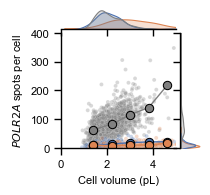

In [101]:
POLR2A_Plot_Vehicle = POLR2A_Plot.query('TREATMENT == "Vehicle"')
POLR2A_Plot_TPL = POLR2A_Plot.query('TREATMENT == "Triptolide"')
POLR2A_Plot_AZD = POLR2A_Plot.query('TREATMENT == "AZD4573"')

POLR2A_Plot_Vehicle_Mean = POLR2A_Plot_Vehicle[['CellVolume', 'SPOTS_PER_CELL']].groupby(pd.cut(POLR2A_Plot_Vehicle.CellVolume, binz)).mean()
POLR2A_Plot_TPL_Mean = POLR2A_Plot_TPL[['CellVolume', 'SPOTS_PER_CELL']].groupby(pd.cut(POLR2A_Plot_TPL.CellVolume, binz)).mean()
POLR2A_Plot_AZD_Mean = POLR2A_Plot_AZD[['CellVolume', 'SPOTS_PER_CELL']].groupby(pd.cut(POLR2A_Plot_AZD.CellVolume, binz)).mean()

sns.set_context('paper')

pal = sns.color_palette(['grey'] + sns.color_palette('deep')[:2])

sns.jointplot(POLR2A_Plot,
              x = 'CellVolume',
              y = 'SPOTS_PER_CELL',
              hue = 'TREATMENT', hue_order = ['Vehicle', 'Triptolide', 'AZD4573'],
              palette = pal,
              marginal_kws=dict(common_norm = False),
              xlim = (0,5),
              ylim = (0,400),
              height = 1.8,
              legend = False,
              s = 8,
              joint_kws = {'alpha' : 0.3})

sns.lineplot(x = binz_centre,
             y = POLR2A_Plot_Vehicle_Mean.SPOTS_PER_CELL,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[0])

sns.lineplot(x = binz_centre,
             y = POLR2A_Plot_TPL_Mean.SPOTS_PER_CELL,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[1])

sns.lineplot(x = binz_centre,
             y = POLR2A_Plot_AZD_Mean.SPOTS_PER_CELL,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[2])

plt.xlabel('Cell volume (pL)', fontsize = 8)
plt.ylabel('$POLR2A$ spots per cell', fontsize = 8)
plt.tick_params(axis = 'both', labelsize = 8)

plt.savefig('VEH_TPL_AZD_POLR2Aspots_2repeats.svg')

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site

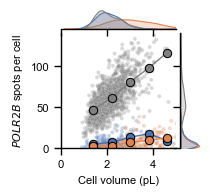

In [102]:
POLR2B_Plot_Vehicle = POLR2B_Plot.query('TREATMENT == "Vehicle"')
POLR2B_Plot_TPL = POLR2B_Plot.query('TREATMENT == "Triptolide"')
POLR2B_Plot_AZD = POLR2B_Plot.query('TREATMENT == "AZD4573"')

POLR2B_Plot_Vehicle_Mean = POLR2B_Plot_Vehicle[['CellVolume', 'SPOTS_PER_CELL']].groupby(pd.cut(POLR2B_Plot_Vehicle.CellVolume, binz)).mean()
POLR2B_Plot_TPL_Mean = POLR2B_Plot_TPL[['CellVolume', 'SPOTS_PER_CELL']].groupby(pd.cut(POLR2B_Plot_TPL.CellVolume, binz)).mean()
POLR2B_Plot_AZD_Mean = POLR2B_Plot_AZD[['CellVolume', 'SPOTS_PER_CELL']].groupby(pd.cut(POLR2B_Plot_AZD.CellVolume, binz)).mean()

sns.set_context('paper')

pal = sns.color_palette(['grey'] + sns.color_palette('deep')[:2])

sns.jointplot(POLR2B_Plot,
              x = 'CellVolume',
              y = 'SPOTS_PER_CELL',
              hue = 'TREATMENT', hue_order = ['Vehicle', 'Triptolide', 'AZD4573'],
              palette = pal,
              marginal_kws=dict(common_norm = False),
              xlim = (0,5),
              ylim = (0,140),
              height = 1.8,
              legend = False,
              s = 8,
              joint_kws = {'alpha' : 0.3})

sns.lineplot(x = binz_centre,
             y = POLR2B_Plot_Vehicle_Mean.SPOTS_PER_CELL,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[0])

sns.lineplot(x = binz_centre,
             y = POLR2B_Plot_TPL_Mean.SPOTS_PER_CELL,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[1])

sns.lineplot(x = binz_centre,
             y = POLR2B_Plot_AZD_Mean.SPOTS_PER_CELL,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[2])

plt.xlabel('Cell volume (pL)', fontsize = 8)
plt.ylabel('$POLR2B$ spots per cell', fontsize = 8)
plt.tick_params(axis = 'both', labelsize = 8)

plt.savefig('VEH_TPL_AZD_POLR2Bspots_2repeats.svg')

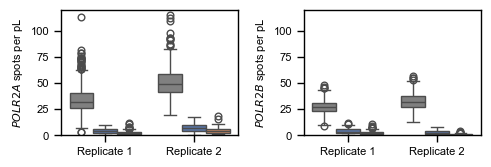

In [103]:
f, a = plt.subplots(figsize = (5,1.8), ncols = 2)

pal = sns.color_palette(['grey', sns.color_palette('deep')[0], sns.color_palette('deep')[1]])

h = sns.boxplot(POLR2A_Plot,
            ax = a[0],
            x = 'REPLICATE',
            y = 'SPOTS_PER_PL',
            hue = 'TREATMENT', palette = pal)
h.get_legend().remove()

h = sns.boxplot(POLR2B_Plot,
            ax = a[1],
            x = 'REPLICATE',
            y = 'SPOTS_PER_PL',
            hue = 'TREATMENT', palette = pal)
h.get_legend().remove()

a[0].set_ylabel('$POLR2A$ spots per pL', fontsize = 8)
a[0].set_xlabel('')
a[0].tick_params(axis = 'both', labelsize = 8)
a[0].set_ylim(0,120)

a[1].set_ylabel('$POLR2B$ spots per pL', fontsize = 8)
a[1].set_xlabel('')
a[1].tick_params(axis = 'both', labelsize = 8)
a[1].set_ylim(0,120)

plt.tight_layout()

plt.savefig('POLR2A_POLR2A_TPL_AZD_2repeats.svg')

In [104]:
Vehicle_AZD_TPL_ByReplicate = POLR2A_Plot[['REPLICATE', 'TREATMENT', 'SPOTS_PER_PL']].groupby(['REPLICATE', 'TREATMENT']).mean().reset_index()

In [105]:
Vehicle_AZD_TPL_ByReplicate

,REPLICATE,TREATMENT,SPOTS_PER_PL
0,Replicate 1,AZD4573,2.509282
1,Replicate 1,Triptolide,4.264938
2,Replicate 1,Vehicle,33.974940
3,Replicate 2,AZD4573,4.883798
4,Replicate 2,Triptolide,7.368595
5,Replicate 2,Vehicle,51.012531


# combine plot of CB6644, AZD4573, and triptolide

In [113]:
Vehicle_CB6644_ByReplicate = Vehicle_CB6644_ByReplicate.rename(columns = {"Spots633_per_pL" : "SPOTS_PER_PL"})

In [107]:
# vehicle replicate 1 in AZD/TPL is shared with vehicle CB6644 (251031_mACmChPOLR2A_smFISH) drop

In [109]:
Vehicle_AZD_TPL_ByReplicate = Vehicle_AZD_TPL_ByReplicate.query('~(REPLICATE == "Replicate 1" & TREATMENT == "Vehicle")')

In [115]:
Vehicle_AZD_TPL_CB6644_Replicates = pd.concat([Vehicle_AZD_TPL_ByReplicate, Vehicle_CB6644_ByReplicate])

In [118]:
Vehicle_AZD_TPL_CB6644_Replicates.TREATMENT.unique()

array(['AZD4573', 'Triptolide', 'Vehicle', 'CB6644'], dtype=object)

In [132]:
Vehicle_AZD_TPL_CB6644_Replicates

,REPLICATE,TREATMENT,SPOTS_PER_PL
0,Replicate 1,AZD4573,2.509282
1,Replicate 1,Triptolide,4.264938
3,Replicate 2,AZD4573,4.883798
4,Replicate 2,Triptolide,7.368595
5,Replicate 2,Vehicle,51.012531
0,Replicate 1,CB6644,81.252033
1,Replicate 1,Vehicle,37.570972
2,Replicate 2,CB6644,57.116260
3,Replicate 2,Vehicle,24.513867
4,Replicate 3,CB6644,72.293866


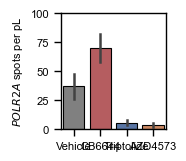

In [138]:
f, a = plt.subplots(ncols = 1, figsize = (4,1.5), layout = 'constrained')

pal =  sns.color_palette(['grey', sns.color_palette('deep')[3], sns.color_palette('deep')[0], sns.color_palette('deep')[1]])

sns.barplot(Vehicle_AZD_TPL_CB6644_Replicates,
            x = 'TREATMENT', order = ['Vehicle', 'CB6644', 'Triptolide', 'AZD4573'],
            hue = 'TREATMENT',
            hue_order = ['Vehicle', 'CB6644', 'Triptolide', 'AZD4573'],
            palette = pal,
            edgecolor = 'black',
            y = 'SPOTS_PER_PL',
            errorbar = 'sd')

a.set_box_aspect(1.1)

a.set_ylabel('$POLR2A$ spots per pL', fontsize = 8)
a.set_ylim(0,100)
a.set_yticks([0, 25, 50, 75, 100])

a.set_xlabel('')

a.tick_params(axis = 'both', labelsize = 8)

plt.savefig('POLR2A_spots_per_pL_CB6644_AZD_TPL.svg')